1. RF classifier (no hyperparameter tuning)
2. MS degree centrality percentile 

In [1]:
import pandas as pd
import numpy as np
import ast
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from scipy.stats import mannwhitneyu
from scipy.stats import spearmanr, pearsonr
from tqdm import trange
import matplotlib.ticker as ticker
import seaborn as sns
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    balanced_accuracy_score, f1_score, precision_score, recall_score,
    roc_auc_score, classification_report, confusion_matrix, roc_curve
)
import shap

#DATA_PATH1 = "../../0-download-inputs/data-files/"
DATA_PATH2 = "../../18-finalize/processed-data/"
#DATA_PATH3 = "../../18-Y2H-data/processed-data/"
#ABUNDANCE  = "../../0-download-inputs/data-files/1-s2.0-S240547121730546X-mmc5.csv" # required to join with Y2H dataset
OUT_PATH   = "figures/"
MS_COLOR   = "#DDAA33"
Y2H_COLOR  = "#BB5566"
MS_COLOR_LIGHT = "#EECC66" #color for static (in complex)
MS_COLOR_DARK  = "#997700" #color for dynamic (not in complex)

plt.rcParams.update({
    "figure.dpi": 300,
    "savefig.dpi": 300,
    "axes.titlesize": 14,
    "axes.titlepad": 25,
    "font.family": "sans-serif",
    "font.sans-serif": "Arial",
    "figure.facecolor": "white",
    "axes.facecolor": "white"
})

In [2]:
# load the datasets with node centrality information and get nodes in both
#ms_nodes = pd.read_pickle(f"{DATA_PATH2}20251023-s288c-annotated-PPI-net.pkl")
#y2h_nodes = pd.read_csv(f"{DATA_PATH3}Y2H-s288c-step18.csv")
nodes = pd.read_pickle(f"{DATA_PATH2}20260210-s288c-ANnnotated-Yeast-Interactome.pkl")

# --- Flip sign of cagiada-dG ---
nodes["cagiada-dG"] = -nodes["cagiada-dG"]

# CHAPERONE CATEGORY: three-way classification ===
def fix_list(val):
    if isinstance(val, list):
        return val
    elif isinstance(val, str):
        try:
            return ast.literal_eval(val)
        except:
            return []
    elif pd.isnull(val):
        return []
    else:
        return []

nodes['interacting_chaperones'] = nodes['interacting_chaperones'].apply(fix_list)

def chaperone_category(row):
    node = row['node']
    chaps = row['interacting_chaperones']
    if not chaps or chaps == []:
        return 'protein_is_neither_chaperone_nor_interacts'
    elif node in chaps:
        return 'protein_is_chaperone'
    else:
        return 'protein_interacts_with_chaperone'

nodes['chaperone_category'] = nodes.apply(chaperone_category, axis=1)

# ONE-HOT ENCODE CHAPERONE CATEGORY
nodes['is_chaperone'] = (nodes['chaperone_category'] == 'protein_is_chaperone').astype(int)
nodes['interacts_with_chaperone'] = (nodes['chaperone_category'] == 'protein_interacts_with_chaperone').astype(int)
nodes['neither_chaperone_nor_interacts'] = (nodes['chaperone_category'] == 'protein_is_neither_chaperone_nor_interacts').astype(int)

#y2h_nodes = y2h_nodes.merge(abundance_df, on="node", how="left")

#shared_nodes = set(ms_nodes["node"]) & set(y2h_nodes["node"])
#print (f"A total of {len(shared_nodes)} nodes are shared between the MS and Y2H networks")
#list(nodes.columns)


In [3]:
# Filter nodes to remove proteins with low pLDDT and/or are membrane proteins (TM) with/without signal peptide (SP)
filtered_nodes = nodes[
    (nodes['mean_plddt'] >= 70) &
    (~nodes['DeepTMHMM_class'].isin(['SP', 'TM', 'SP+TM']))
].copy()

# Print stats to for nodes
print(f"Original rows: {len(nodes)}")
print(f"Filtered rows: {len(filtered_nodes)}")

Original rows: 3927
Filtered rows: 2466


In [4]:
# determine which nodes are hubs based on percentile cutoff for degree centrality
cut = 0.10
ms_threshold = filtered_nodes['degree_centrality'].quantile(1 - cut)
ms_hubs     = filtered_nodes[filtered_nodes['degree_centrality'] >= ms_threshold]
ms_nothub   = filtered_nodes[filtered_nodes['degree_centrality'] <  ms_threshold]

#y2h_threshold = filtered_nodes['Y2H_degree_centrality'].quantile(1 - cut)
#y2h_hubs      = filtered_nodes[filtered_nodes['Y2H_degree_centrality'] >= y2h_threshold]
#y2h_nothub    = filtered_nodes[filtered_nodes['Y2H_degree_centrality'] <  y2h_threshold]

print(f"Threshold for defining a hub in MS data is {ms_threshold:.5f}; there are {len(ms_hubs)} hubs and {len(ms_nothub)} non hubs")
#print(f"Threshold for defining a hub in Y2H data is {y2h_threshold:.5f}; there are {len(y2h_hubs)} hubs and {len(y2h_nothub)} non hubs")

Threshold for defining a hub in MS data is 0.01503; there are 252 hubs and 2214 non hubs


In [5]:
# SCRIPT 2: Feature & Target Preparation
# Create target column if not already created
filtered_nodes['ms_hubs'] = (filtered_nodes['degree_centrality'] >= ms_threshold).astype(int)

# 2. Feature & Target Preparation
ml_features = [
    'Ghosh-Dill-dG', 'cagiada-dG', 'Rosetta_best_total_score',
    'Villen_halflife_min',
    'mean_molecules_per_cell',
    'interacts_with_chaperone', 'in_complex',
    'essential',
    'meltome-melting-point', 'N_aa_disordered', 'disorder_fraction', 'mean_plddt'
]

X = filtered_nodes[ml_features].copy()
y = filtered_nodes['ms_hubs'].copy()

# Replace common string indicators of missing values with NaN, then convert to numeric
missing_indicators = [
    'n.d.', 'N.D.', 'nd', 'ND', 'na', 'NA', 'null', 'NULL',
    'missing', 'MISSING', '-', 'n/a', 'N/A', ''
]

for col in ml_features:
    X[col] = X[col].replace(missing_indicators, np.nan)
    X[col] = pd.to_numeric(X[col], errors='coerce')

# Fill remaining NaNs with -999 (important for sklearn RF)
X_filled = X.fillna(-999)

print("✅ Data preparation complete")
print(f"Total usable samples: {len(X_filled)}")

✅ Data preparation complete
Total usable samples: 2466


In [6]:
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    balanced_accuracy_score, f1_score, precision_score, recall_score,
    roc_auc_score, roc_curve, confusion_matrix
)

# -------------------------------------------
# Repeated train/test evaluation
# -------------------------------------------
n_models = 50
test_size = 0.2
base_random_state = 42

splitter = StratifiedShuffleSplit(
    n_splits=n_models,
    test_size=test_size,
    random_state=base_random_state
)

results = []
feature_importances_list = []
roc_curves = []

fpr_grid = np.linspace(0, 1, 100)

last_model = None
last_X_test = None
last_y_test = None

for i, (train_idx, test_idx) in enumerate(splitter.split(X_filled, y), start=1):
    X_train = X_filled.iloc[train_idx]
    X_test  = X_filled.iloc[test_idx]
    y_train = y.iloc[train_idx]
    y_test  = y.iloc[test_idx]

    rf_model = RandomForestClassifier(
        n_estimators=200,          # trees INSIDE each RF model
        max_depth=10,
        min_samples_split=5,
        class_weight='balanced',
        random_state=base_random_state + i
    )

    rf_model.fit(X_train, y_train)

    y_pred = rf_model.predict(X_test)
    y_proba = rf_model.predict_proba(X_test)[:, 1]

    bal_acc = balanced_accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, zero_division=0)
    recall = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)

    if len(np.unique(y_test)) == 2:
        roc_auc = roc_auc_score(y_test, y_proba)
        fpr, tpr, _ = roc_curve(y_test, y_proba)
        interp_tpr = np.interp(fpr_grid, fpr, tpr)
        interp_tpr[0] = 0.0
        roc_curves.append(interp_tpr)
    else:
        roc_auc = np.nan

    cm = confusion_matrix(y_test, y_pred)
    tn, fp, fn, tp = cm.ravel()

    results.append({
        "model_num": i,
        "balanced_accuracy": bal_acc,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "roc_auc": roc_auc,
        "tn": tn,
        "fp": fp,
        "fn": fn,
        "tp": tp
    })

    feature_importances_list.append(rf_model.feature_importances_)

    # Keep last model for SHAP
    last_model = rf_model
    last_X_test = X_test.copy()
    last_y_test = y_test.copy()

results_df = pd.DataFrame(results)

print("✅ 50-model evaluation complete")
print(results_df.describe())

✅ 50-model evaluation complete
       model_num  balanced_accuracy  precision    recall         f1  \
count   50.00000          50.000000  50.000000  50.00000  50.000000   
mean    25.50000           0.717365   0.675308   0.46000   0.544637   
std     14.57738           0.034522   0.071984   0.06869   0.063156   
min      1.00000           0.651982   0.515152   0.34000   0.409639   
25%     13.25000           0.697894   0.631685   0.42000   0.505703   
50%     25.50000           0.712613   0.676548   0.46000   0.538894   
75%     37.75000           0.738457   0.729730   0.50000   0.583551   
max     50.00000           0.795495   0.882353   0.60000   0.714286   

         roc_auc          tn         fp         fn         tp  
count  50.000000   50.000000  50.000000  50.000000  50.000000  
mean    0.897915  432.780000  11.220000  27.000000  23.000000  
std     0.025665    3.430297   3.430297   3.434519   3.434519  
min     0.834572  422.000000   4.000000  20.000000  17.000000  
25%     0

In [7]:
metrics_to_summarize = ["balanced_accuracy", "precision", "recall", "f1", "roc_auc"]

print("\nModel Performance Across 50 Runs:")
for metric in metrics_to_summarize:
    mean_val = results_df[metric].mean()
    std_val = results_df[metric].std()
    print(f"{metric}: {mean_val:.3f} ± {std_val:.3f}")


Model Performance Across 50 Runs:
balanced_accuracy: 0.717 ± 0.035
precision: 0.675 ± 0.072
recall: 0.460 ± 0.069
f1: 0.545 ± 0.063
roc_auc: 0.898 ± 0.026


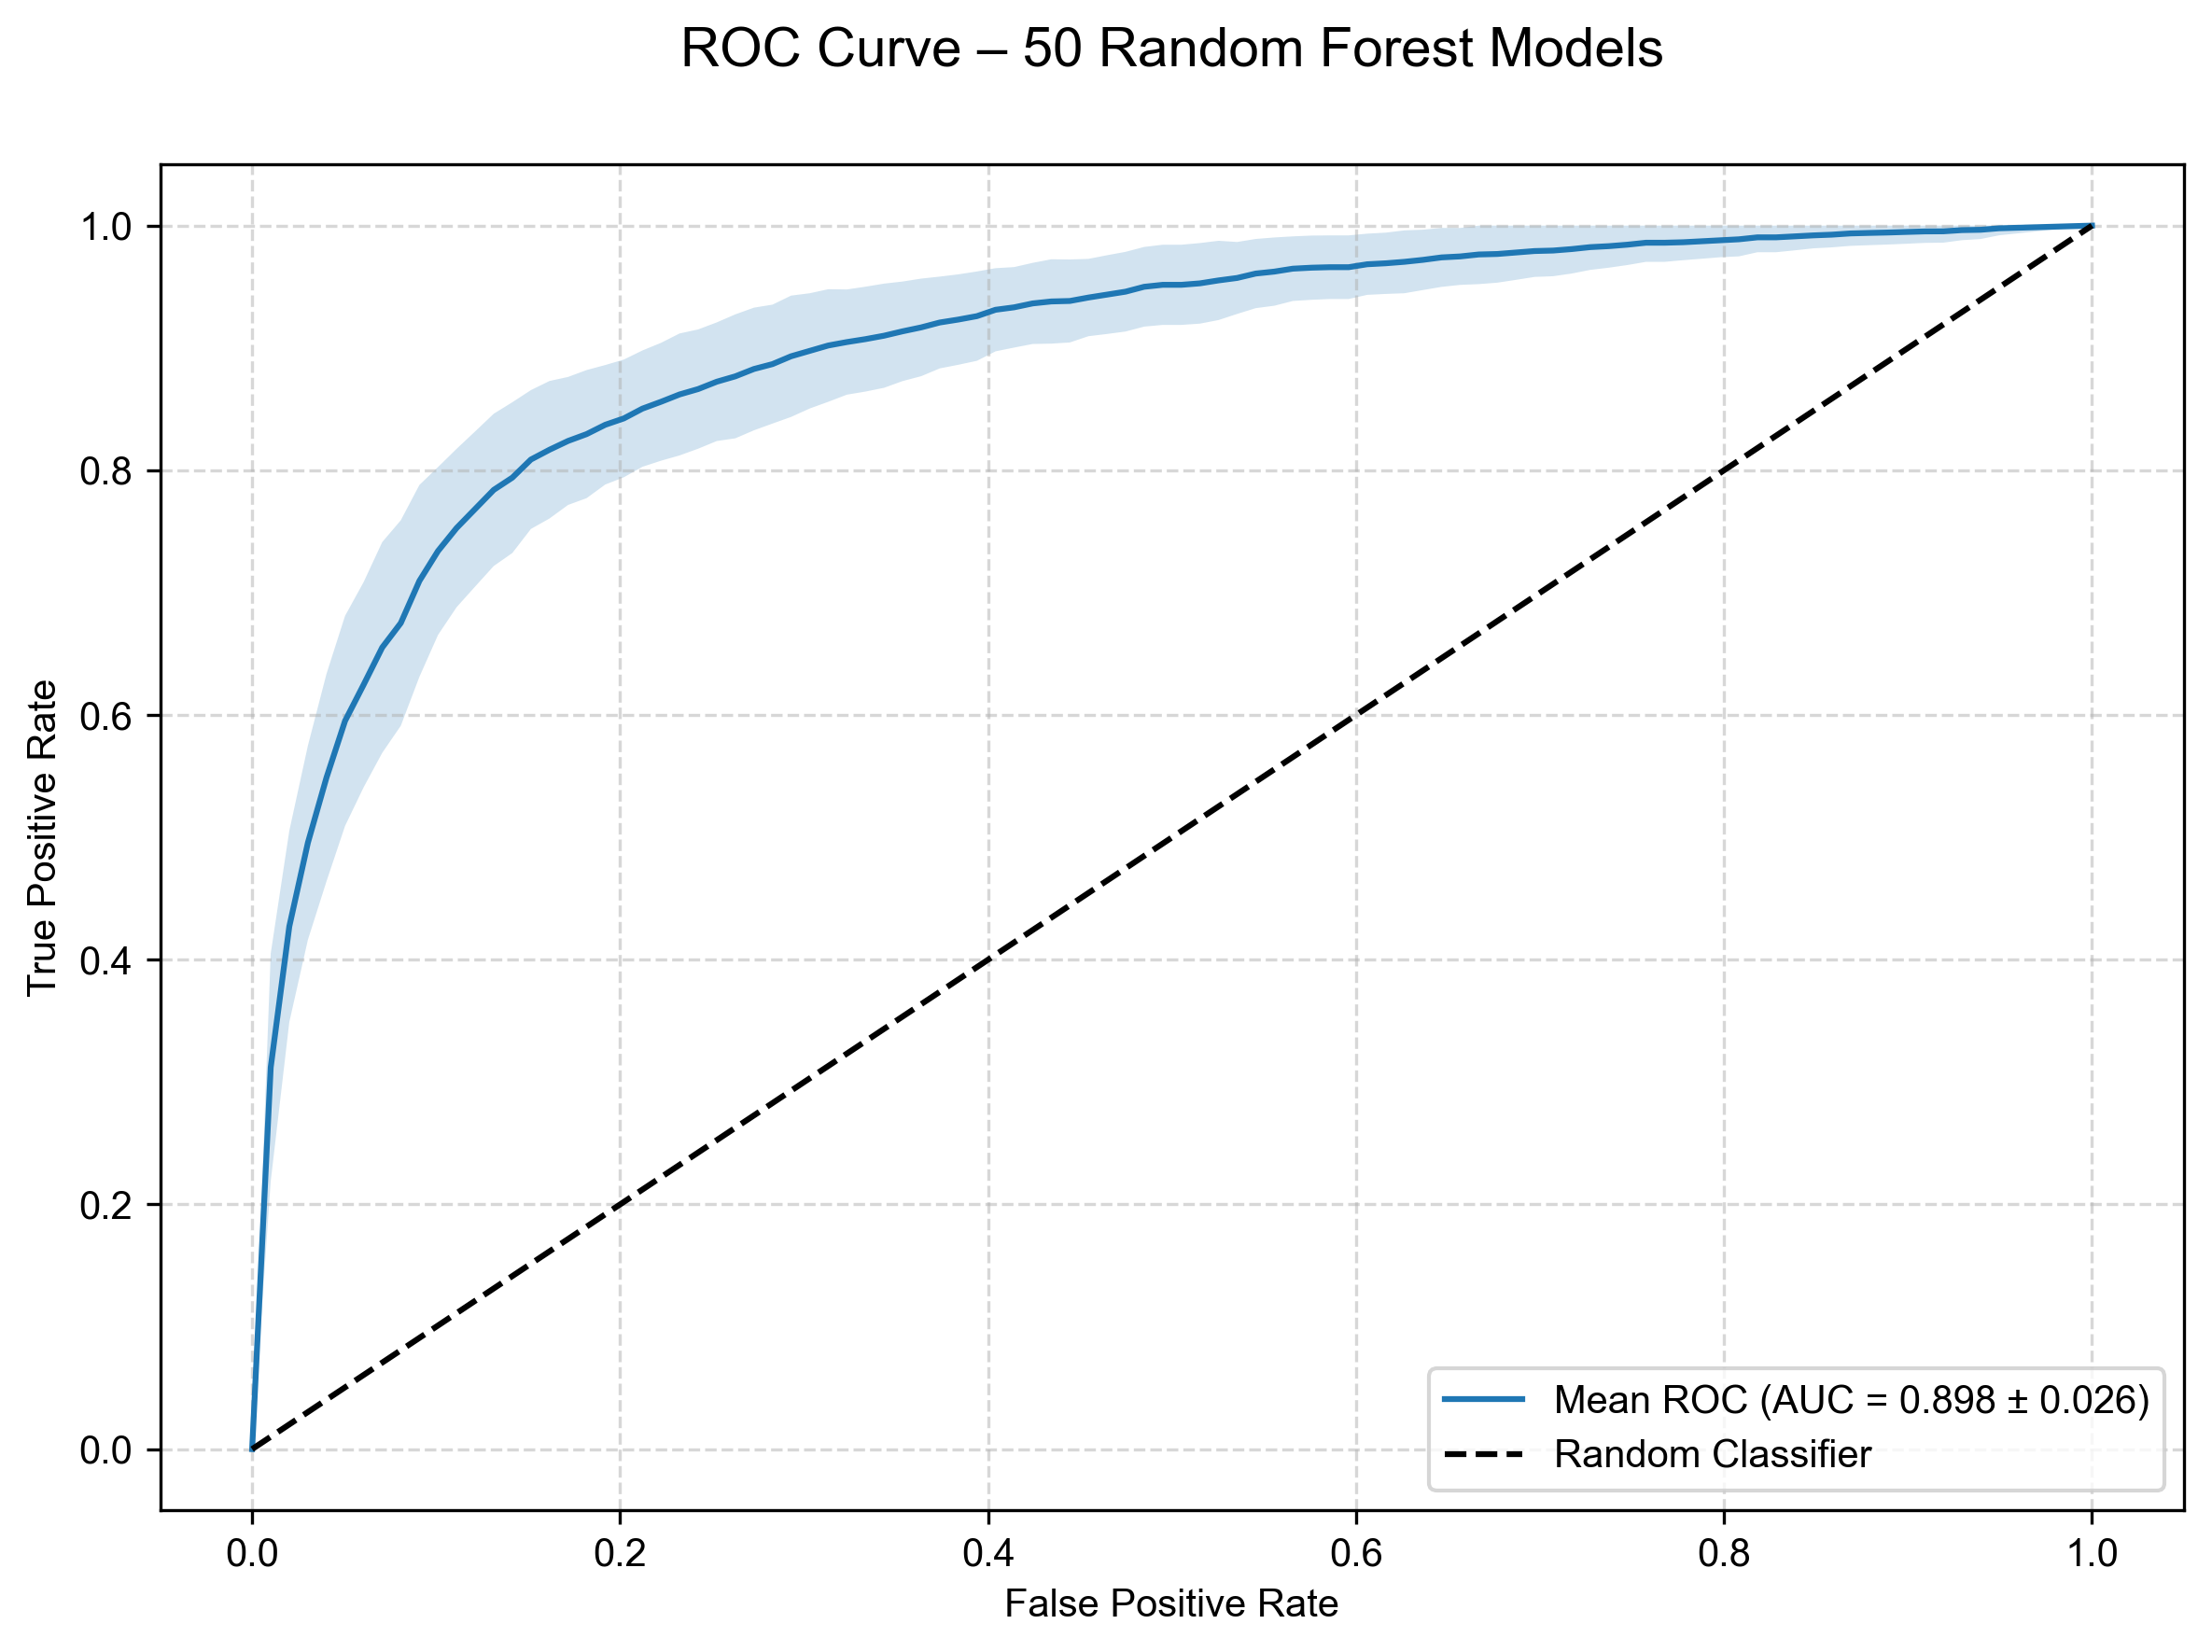

In [8]:
mean_tpr = np.mean(roc_curves, axis=0)
std_tpr = np.std(roc_curves, axis=0)
mean_auc = results_df["roc_auc"].mean()
std_auc = results_df["roc_auc"].std()

# -------------------------------------------
# Save ROC data to Excel
# -------------------------------------------
roc_export_df = pd.DataFrame({
    "False_Positive_Rate": fpr_grid,
    "True_Positive_Rate": mean_tpr
})

# -------------------------------------------
# Plot ROC curve
# -------------------------------------------
roc_export_df.to_excel("roc_model1.xlsx", index=False)

plt.figure(figsize=(8, 6))
plt.plot(fpr_grid, mean_tpr, label=f"Mean ROC (AUC = {mean_auc:.3f} ± {std_auc:.3f})")
plt.fill_between(
    fpr_grid,
    np.maximum(mean_tpr - std_tpr, 0),
    np.minimum(mean_tpr + std_tpr, 1),
    alpha=0.2
)
plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve – 50 Random Forest Models")
plt.legend(loc="lower right")
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

In [9]:
feature_importances_array = np.array(feature_importances_list)

importance_df = pd.DataFrame({
    "Feature": X_filled.columns,
    "Mean_Gini_Importance": feature_importances_array.mean(axis=0),
    "SD_Gini_Importance": feature_importances_array.std(axis=0)
}).sort_values(by="Mean_Gini_Importance", ascending=False)

print("\nMean Gini Feature Importances Across 50 Runs:")
print(importance_df.to_string(index=False))


Mean Gini Feature Importances Across 50 Runs:
                 Feature  Mean_Gini_Importance  SD_Gini_Importance
 mean_molecules_per_cell              0.218598            0.008061
     Villen_halflife_min              0.180503            0.009829
              cagiada-dG              0.091959            0.006701
   meltome-melting-point              0.085094            0.005761
Rosetta_best_total_score              0.084216            0.004538
              mean_plddt              0.081114            0.004725
           Ghosh-Dill-dG              0.075562            0.003629
       disorder_fraction              0.057610            0.003810
         N_aa_disordered              0.052473            0.003116
               essential              0.030904            0.003904
interacts_with_chaperone              0.022031            0.003277
              in_complex              0.019937            0.002810


In [10]:
# ===========================================
# MEAN ABSOLUTE SHAP ACROSS ALL 50 MODELS
# + pooled beeswarm
# ===========================================

import shap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.ensemble import RandomForestClassifier

# -----------------------------
# display names
# -----------------------------
rename_map = {
    'Ghosh-Dill-dG': 'Ghosh & Dill 2010 ΔG(L, T)', 
    'cagiada-dG': 'Cagiada et al. 2025 ΔG', 
    'Rosetta_best_total_score': 'Rosetta total score (REU)',
    'Villen_halflife_min': 'Protein half-life (min)',
    'mean_molecules_per_cell': 'Molecular abundance',
    'interacts_with_chaperone': 'Chaperone interaction', 
    'in_complex': 'In complex',
    'essential': 'Essential',
    'meltome-melting-point': 'Melting point (°C)',  
    'N_aa_disordered': r"$N_{\mathrm{disordered}}$",
    'disorder_fraction': 'Disorder fraction', 
    'mean_plddt': 'Mean pLDDT'
}

# -----------------------------
# Recreate the same 50 splits
# -----------------------------
splitter_shap = StratifiedShuffleSplit(
    n_splits=n_models,
    test_size=test_size,
    random_state=base_random_state
)

# storage
mean_abs_shap_list = []
all_shap_values = []
all_X_test = []

print("Computing SHAP across all 50 models...")

for i, (train_idx, test_idx) in enumerate(splitter_shap.split(X_filled, y), start=1):
    print(f"SHAP model {i}/{n_models}")

    X_train = X_filled.iloc[train_idx]
    X_test  = X_filled.iloc[test_idx]
    y_train = y.iloc[train_idx]
    y_test  = y.iloc[test_idx]

    # same RF settings as your main analysis
    rf_model = RandomForestClassifier(
        n_estimators=200,
        max_depth=10,
        min_samples_split=5,
        class_weight='balanced',
        random_state=base_random_state + i
    )
    rf_model.fit(X_train, y_train)

    # SHAP
    explainer = shap.TreeExplainer(rf_model)
    shap_values = explainer.shap_values(X_test)

    # Handle different SHAP output formats
    if isinstance(shap_values, list):
        shap_class_values = shap_values[1]
    elif hasattr(shap_values, "ndim") and shap_values.ndim == 3:
        shap_class_values = shap_values[:, :, 1]
    else:
        shap_class_values = shap_values

    # mean absolute SHAP for this model
    mean_abs_shap = np.abs(shap_class_values).mean(axis=0)
    mean_abs_shap_list.append(mean_abs_shap)

    # store for pooled beeswarm
    all_shap_values.append(shap_class_values)
    all_X_test.append(X_test.copy())

print("✅ SHAP calculation across 50 models completed.")

Computing SHAP across all 50 models...
SHAP model 1/50
SHAP model 2/50
SHAP model 3/50
SHAP model 4/50
SHAP model 5/50
SHAP model 6/50
SHAP model 7/50
SHAP model 8/50
SHAP model 9/50
SHAP model 10/50
SHAP model 11/50
SHAP model 12/50
SHAP model 13/50
SHAP model 14/50
SHAP model 15/50
SHAP model 16/50
SHAP model 17/50
SHAP model 18/50
SHAP model 19/50
SHAP model 20/50
SHAP model 21/50
SHAP model 22/50
SHAP model 23/50
SHAP model 24/50
SHAP model 25/50
SHAP model 26/50
SHAP model 27/50
SHAP model 28/50
SHAP model 29/50
SHAP model 30/50
SHAP model 31/50
SHAP model 32/50
SHAP model 33/50
SHAP model 34/50
SHAP model 35/50
SHAP model 36/50
SHAP model 37/50
SHAP model 38/50
SHAP model 39/50
SHAP model 40/50
SHAP model 41/50
SHAP model 42/50
SHAP model 43/50
SHAP model 44/50
SHAP model 45/50
SHAP model 46/50
SHAP model 47/50
SHAP model 48/50
SHAP model 49/50
SHAP model 50/50
✅ SHAP calculation across 50 models completed.


In [11]:
# ===========================================
# SUMMARIZE MEAN ABSOLUTE SHAP
# ===========================================

mean_abs_shap_array = np.array(mean_abs_shap_list)

shap_importance_df = pd.DataFrame({
    "Feature": X_filled.columns,
    "Display_Name": [rename_map.get(f, f) for f in X_filled.columns],
    "Mean_Abs_SHAP": mean_abs_shap_array.mean(axis=0),
    "SD_Abs_SHAP": mean_abs_shap_array.std(axis=0)
}).sort_values(by="Mean_Abs_SHAP", ascending=False)

print("\nMean Absolute SHAP Across 50 Models:")
print(shap_importance_df.to_string(index=False))

# save table
#shap_importance_df.to_csv("mean_abs_shap_50models.csv", index=False)
#print("\nSaved: mean_abs_shap_50models.csv")


Mean Absolute SHAP Across 50 Models:
                 Feature               Display_Name  Mean_Abs_SHAP  SD_Abs_SHAP
 mean_molecules_per_cell        Molecular abundance       0.097112     0.004921
     Villen_halflife_min    Protein half-life (min)       0.095176     0.005500
              cagiada-dG     Cagiada et al. 2025 ΔG       0.047466     0.004916
   meltome-melting-point         Melting point (°C)       0.038290     0.004125
Rosetta_best_total_score  Rosetta total score (REU)       0.033844     0.003019
              mean_plddt                 Mean pLDDT       0.032167     0.003021
           Ghosh-Dill-dG Ghosh & Dill 2010 ΔG(L, T)       0.028763     0.002133
       disorder_fraction          Disorder fraction       0.025516     0.002543
         N_aa_disordered  $N_{\mathrm{disordered}}$       0.022582     0.002133
               essential                  Essential       0.021752     0.003150
              in_complex                 In complex       0.017483     0.003060
in

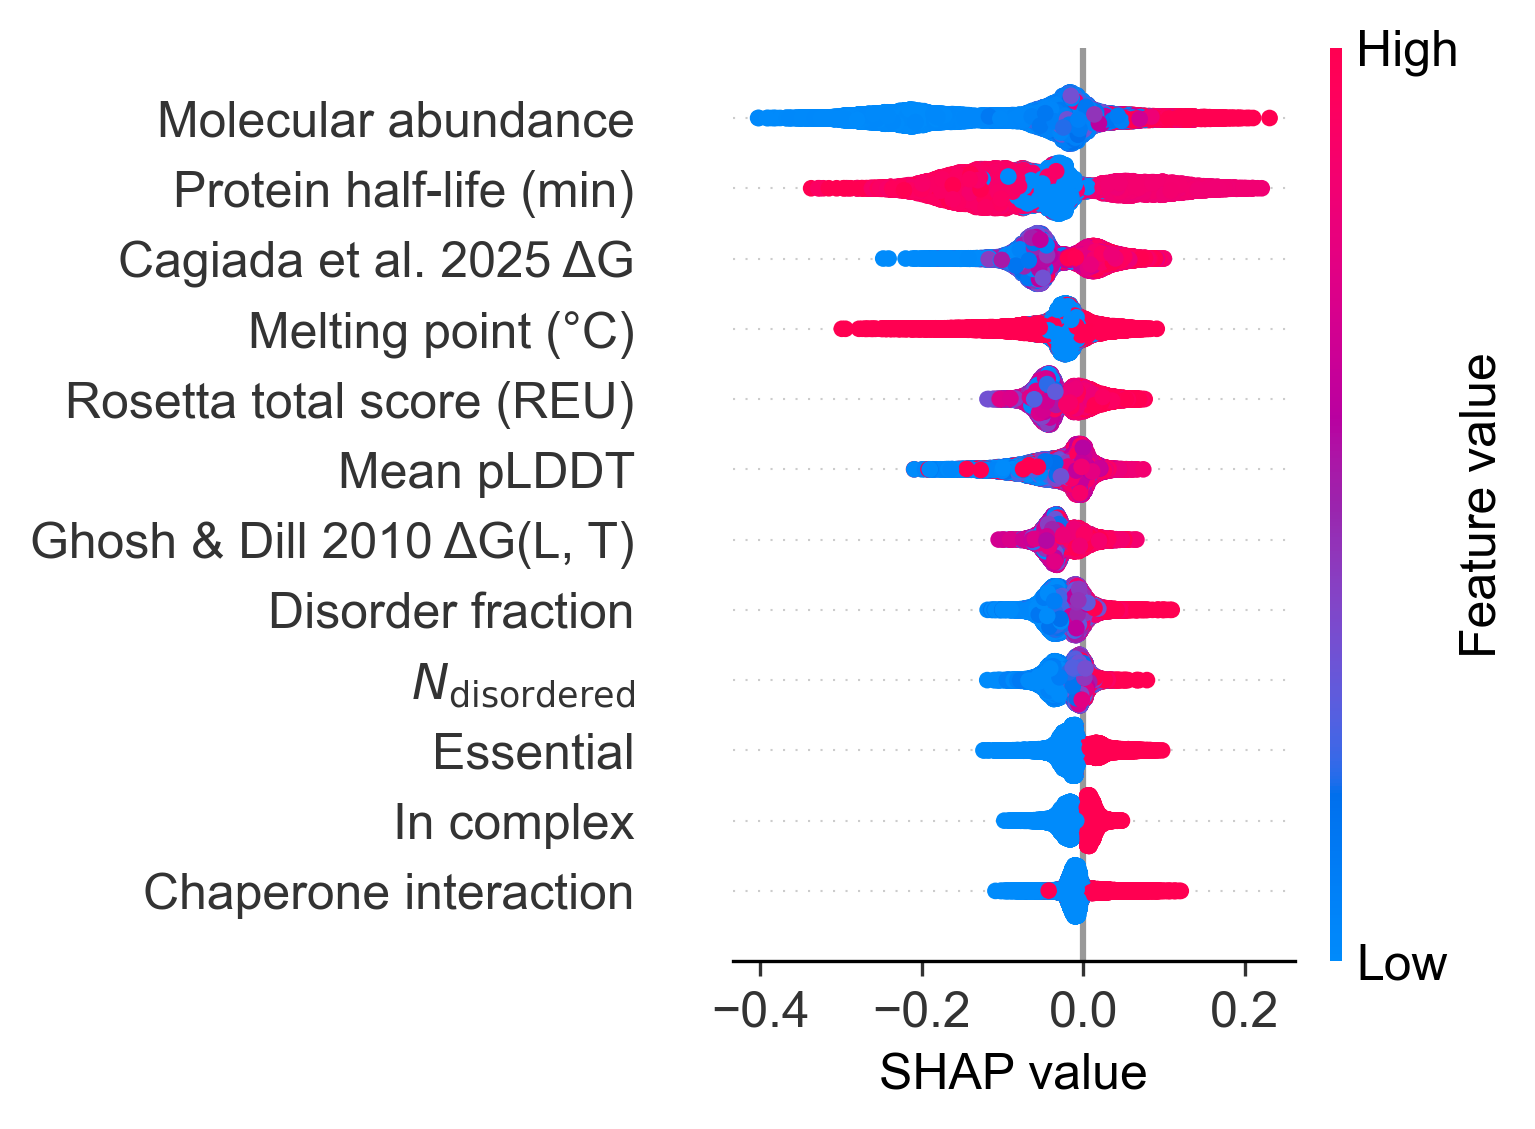

In [12]:
# ===========================================
# POOLED BEESWARM ACROSS ALL 50 MODELS
# ===========================================

pooled_shap_values = np.vstack(all_shap_values)
pooled_X_test = pd.concat(all_X_test, axis=0)

display_names = [rename_map.get(f, f) for f in pooled_X_test.columns]

fig, ax = plt.subplots(figsize=(3.5, 3.5))
shap.summary_plot(
    pooled_shap_values,
    pooled_X_test,
    feature_names=display_names,
    plot_type='dot',
    max_display=12,
    show=False
)

fig = plt.gcf()
ax = plt.gca()

# font cleanup
for text in fig.findobj(match=plt.Text):
    text.set_fontfamily("Arial")
    text.set_fontsize(12)
    text.set_fontweight("normal")

ax.set_xlabel("SHAP value", fontsize=12, fontweight="normal", fontfamily="Arial")
ax.set_ylabel("", fontsize=12, fontweight="normal", fontfamily="Arial")

for label in ax.get_xticklabels() + ax.get_yticklabels():
    label.set_fontfamily("Arial")
    label.set_fontsize(12)
    label.set_fontweight("normal")

plt.tight_layout()
fig.set_size_inches(3.5, 3.5)
plt.savefig("SHAP_random_forest_1.svg", format="svg", dpi=300, bbox_inches="tight")
plt.show()